# 01 — Regressão Logística: Probabilidade de Churn
## PRT Seguros

Modelo linear de baseline. Usamos `class_weight='balanced'` para compensar o desbalanceamento (~12% de churn) e padronizamos as features com `StandardScaler`, requisito da regressão logística — diferente de modelos baseados em árvore.

## 1. Imports e carregar dados processados

Os dados já vêm prontos do notebook `00_preparacao_dados.ipynb`: **treino e validação já vêm
separados** (o split foi feito antes de qualquer ajuste de imputer/scaler/K-Means, para não vazar
informação da validação para dentro do pré-processamento), com as mesmas features e a mesma
clusterização — para que o AUC-ROC de todos os modelos seja comparável.

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, roc_curve

PRT_NAVY  = "#19284F"
PRT_GREEN = "#39694B"
PRT_GRAY  = "#737C8A"
RANDOM_STATE = 42

train = pd.read_csv("dados_processados/train_model_ready.csv")
val = pd.read_csv("dados_processados/val_model_ready.csv")
kaggle = pd.read_csv("dados_processados/kaggle_model_ready.csv")

ID_COL, TARGET_COL = "cod_individuo", "churned"
feature_cols = [c for c in train.columns if c not in (ID_COL, TARGET_COL)]

X_train, y_train = train[feature_cols], train[TARGET_COL]
X_val, y_val = val[feature_cols], val[TARGET_COL]
X_kaggle = kaggle[feature_cols]

print(f"Treino : {X_train.shape} | churn = {y_train.mean():.1%}")
print(f"Val    : {X_val.shape} | churn = {y_val.mean():.1%}")
print(f"Kaggle : {X_kaggle.shape}")


Treino : (80000, 72) | churn = 12.1%
Val    : (20000, 72) | churn = 12.1%
Kaggle : (100000, 72)


## 2. Treinar o modelo

In [2]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

log_reg = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(
        class_weight="balanced",
        max_iter=2000,
        C=1.0,
        random_state=RANDOM_STATE,
    )),
])

log_reg.fit(X_train, y_train)

proba_val = log_reg.predict_proba(X_val)[:, 1]


## 3. Avaliar no conjunto de validação (AUC-ROC)

A métrica que importa aqui é o **AUC-ROC da probabilidade prevista** (`predict_proba`), não a acurácia da classificação binária — é isso que o projeto pediu para maximizar.

In [3]:
auc_val = roc_auc_score(y_val, proba_val)
print(f"ROC-AUC (validação) — Regressão Logística: {auc_val:.4f}")

ROC-AUC (validação) — Regressão Logística: 0.8020


## 4. Curva ROC

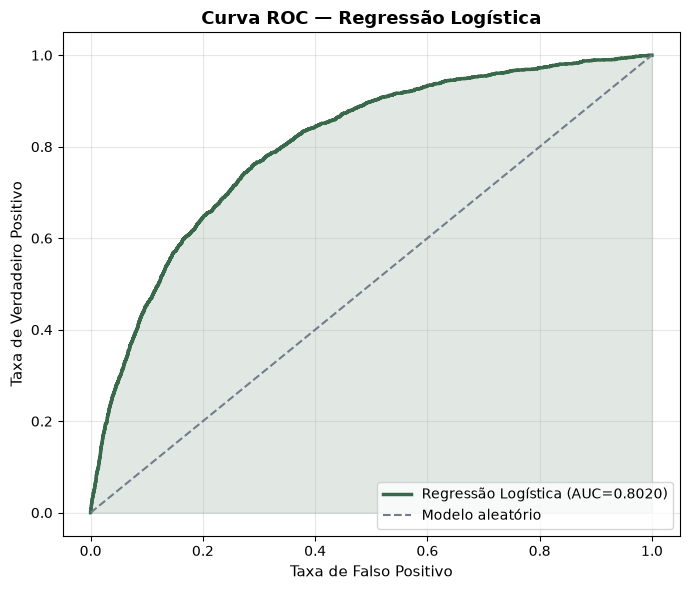

In [4]:
fpr, tpr, _ = roc_curve(y_val, proba_val)

fig, ax = plt.subplots(figsize=(7, 6))
ax.plot(fpr, tpr, label=f"Regressão Logística (AUC={auc_val:.4f})", color=PRT_GREEN, linewidth=2.5)
ax.plot([0, 1], [0, 1], linestyle="--", color=PRT_GRAY, label="Modelo aleatório")
ax.fill_between(fpr, tpr, alpha=0.15, color=PRT_GREEN)
ax.set_xlabel("Taxa de Falso Positivo", fontsize=11)
ax.set_ylabel("Taxa de Verdadeiro Positivo", fontsize=11)
ax.set_title("Curva ROC — Regressão Logística", fontsize=13, fontweight="bold")
ax.legend(loc="lower right", fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## 5. Prever probabilidade de churn na base Kaggle

Aqui geramos a saída que o projeto pediu: uma **probabilidade contínua entre 0 e 1** de churn para cada indivíduo da base de teste (`Base_Unificada_Kaggle_Outer.csv`), não um rótulo binário.

In [5]:
os.makedirs("submissions", exist_ok=True)

proba_kaggle = log_reg.predict_proba(X_kaggle)[:, 1]

submissao = pd.DataFrame({
    "Id": kaggle[ID_COL],
    "probabilidade_churn": proba_kaggle,
})
submissao.to_csv("submissions/submission_logistic_regression.csv", index=False)
print(submissao.head())
print(f"\nProbabilidade média de churn prevista no Kaggle: {proba_kaggle.mean():.2%}")


             Id  probabilidade_churn
0  221300000002             0.096040
1  221300000020             0.281038
2  221300000097             0.145696
3  221300000148             0.289201
4  221300000166             0.481564

Probabilidade média de churn prevista no Kaggle: 39.53%


## 6. Registrar resultado para comparação final

In [6]:
os.makedirs("dados_processados", exist_ok=True)
resultados_path = "dados_processados/resultados_modelos.csv"

linha = pd.DataFrame([{
    "modelo": "logistic_regression",
    "auc_roc_val": auc_val,
}])

if os.path.exists(resultados_path):
    resultados = pd.read_csv(resultados_path)
    resultados = resultados[resultados["modelo"] != "logistic_regression"]
    resultados = pd.concat([resultados, linha], ignore_index=True)
else:
    resultados = linha

resultados.to_csv(resultados_path, index=False)
print(resultados.sort_values("auc_roc_val", ascending=False).to_string(index=False))


             modelo  auc_roc_val
           catboost     0.825413
            xgboost     0.823997
           lightgbm     0.823799
      random_forest     0.819568
        extra_trees     0.806200
logistic_regression     0.801985


## 7. Salvar probabilidades da validação (para blending)

Guardamos `proba_val` em disco — o notebook `08_blending.ipynb` combina as previsões de todos os modelos sobre o **mesmo** conjunto de validação.

In [7]:
os.makedirs("dados_processados/proba_val", exist_ok=True)
pd.DataFrame({
    "cod_individuo": val[ID_COL],
    "proba": proba_val,
}).to_csv("dados_processados/proba_val/logistic_regression.csv", index=False)
print("Salvo: dados_processados/proba_val/logistic_regression.csv")

Salvo: dados_processados/proba_val/logistic_regression.csv


## 8. Registrar no MLflow (SageMaker)

Registra parâmetros, o AUC-ROC de validação e o modelo treinado como uma *run* no MLflow, no
tracking server **`equipe5`** do SageMaker Studio — para que o time (e a PRT Seguros) tenha o
histórico de todo modelo treinado, não só os arquivos CSV locais.

In [8]:
import os
import mlflow
import mlflow.sklearn
from mlflow.models import infer_signature
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    log_loss, average_precision_score,
)

os.environ.setdefault("MLFLOW_SUPPRESS_PRINTING_URL_TO_STDOUT", "true")

MLFLOW_TRACKING_URI = os.environ.get(
    "MLFLOW_TRACKING_URI", "arn:aws:sagemaker:us-east-2:906513713169:mlflow-tracking-server/equipe5"
)
MLFLOW_EXPERIMENT = "churn-prt-seguros"

mlflow.set_tracking_uri(MLFLOW_TRACKING_URI)
mlflow.set_experiment(MLFLOW_EXPERIMENT)

with mlflow.start_run(run_name="logistic_regression"):
    mlflow.log_params(log_reg.named_steps["clf"].get_params())

    preds_val = (proba_val >= 0.5).astype(int)
    mlflow.log_metrics({
        "auc_roc_val": auc_val,
        "accuracy_val": accuracy_score(y_val, preds_val),
        "precision_val": precision_score(y_val, preds_val),
        "recall_val": recall_score(y_val, preds_val),
        "f1_val": f1_score(y_val, preds_val),
        "log_loss_val": log_loss(y_val, proba_val),
        "avg_precision_val": average_precision_score(y_val, proba_val),
    })

    signature = infer_signature(X_train, log_reg.predict(X_train))
    model_info = mlflow.sklearn.log_model(
        log_reg, name="model", signature=signature, input_example=X_train.head(5)
    )

    # curva ROC (gerada na secao 4) fica anexada a esta run tambem
    mlflow.log_figure(fig, "curva_roc.png")

    # importancia de features via coeficientes (top 15, em valor absoluto)
    coefs = pd.Series(log_reg.named_steps["clf"].coef_[0], index=feature_cols)
    importancias = coefs.abs().sort_values(ascending=False).head(15)
    fig_imp, ax_imp = plt.subplots(figsize=(8, 6))
    coefs[importancias.index].sort_values().plot.barh(ax=ax_imp, color=PRT_NAVY)
    ax_imp.set_title("Top 15 coeficientes - Logistic Regression", fontweight="bold")
    ax_imp.set_xlabel("Coeficiente (sinal indica direcao do efeito)")
    ax_imp.axvline(0, color=PRT_GRAY, linewidth=1)
    plt.tight_layout()
    mlflow.log_figure(fig_imp, "feature_importance.png")

    # avaliacao automatica do MLflow: matriz de confusao, curva PR, curva de lift, calibracao
    eval_df = X_val.copy()
    eval_df["churned"] = y_val.values
    mlflow.models.evaluate(
        model=model_info.model_uri,
        data=eval_df,
        targets="churned",
        model_type="classifier",
        evaluator_config={"log_model_explainability": False},
    )

    print(f"Run 'logistic_regression' registrada no MLflow (experimento '{MLFLOW_EXPERIMENT}').")


2026/07/09 20:23:21 WARNING mlflow.tracking.request_header.registry: Encountered unexpected error during resolving request headers: list index out of range


2026/07/09 20:23:22 WARNING mlflow.tracking.request_header.registry: Encountered unexpected error during resolving request headers: list index out of range


2026/07/09 20:23:22 WARNING mlflow.tracking.request_header.registry: Encountered unexpected error during resolving request headers: list index out of range


2026/07/09 20:23:22 WARNING mlflow.tracking.request_header.registry: Encountered unexpected error during resolving request headers: list index out of range


2026/07/09 20:23:59 WARNING mlflow.tracking.request_header.registry: Encountered unexpected error during resolving request headers: list index out of range


...

2026/07/09 20:24:53 WARNING mlflow.tracking.request_header.registry: Encountered unexpected error during resolving request headers: list index out of range


2026/07/09 20:24:53 WARNING mlflow.tracking.request_header.registry: Encountered unexpected error during resolving request headers: list index out of range


2026/07/09 20:24:53 WARNING mlflow.tracking.request_header.registry: Encountered unexpected error during resolving request headers: list index out of range


Run 'logistic_regression' registrada no MLflow (experimento 'churn-prt-seguros').


<Figure size 800x600 with 0 Axes>